<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Distributed Machine Learning </b><br><br>Computer Assignment 3</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Behzad Jannati / CA3 -
        <h1> 810103098 </h1>
        <h1> Dr. Mohammad Javad Dousti
    </div>
</div>

>[DMLS - Computer Assignment 3](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=Y8WST7neIfwW)

>[Question 2: Word2Vec Semantic Word Modeling](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=UwtacPLnJOz0)

>>[Section 0: Environment Setup](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=EVyjeP3MKBz7)

>>[Section 2.1: Train Word2Vec Model](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=YkcNbxZCJ9Yj)

>>[Section 2.2: Extract Word Embedding Vectors](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=lSGCPvhUKMCz)

>>[Section 2.3: Compute Word Similarities](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=2mf258amNmpt)

>>[Section 2.4: Semantic Relationship Analysis](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=yWTRoaVCN5Tj)

>>>[Extra Semantic Relationship Test](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=R27v-Rr5who0)

>>[Visualization of Word Embeddings](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=rzP9Ovylw5pU)



#DMLS - Computer Assignment 3

#Question 2: Word2Vec Semantic Word Modeling

## Section 0: Environment Setup

In [1]:
# =============================================================================
# DMLS - Computer Assignment 3
# Question 2: Word2Vec Semantic Word Modeling
# Based on: https://github.com/apache/spark/blob/master/examples/src/main/python/ml/word2vec_example.py
# =============================================================================

# -----------------------------------------------------------------------------
# Section 0: Environment Setup
# -----------------------------------------------------------------------------

# Install PySpark in Google Colab
!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec, Word2VecModel
from pyspark.sql.functions import split, col, lower, regexp_replace, size
from pyspark.sql.types import ArrayType, StringType
import numpy as np
import pandas as pd

# Initialize Spark Session with optimized settings for Word2Vec
spark = SparkSession.builder \
    .appName("Word2VecSemanticModeling") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# Set log level to reduce output noise
spark.sparkContext.setLogLevel("WARN")

print("=" * 60)
print("✅Spark Session initialized successfully!")
print(f"📌Spark Version: {spark.version}")
print("=" * 60)

✅Spark Session initialized successfully!
📌Spark Version: 4.0.1


## Section 2.1: Train Word2Vec Model

In [2]:
# -----------------------------------------------------------------------------
# Section 2.1: Train Word2Vec Model
# -----------------------------------------------------------------------------
# Task: Train a Word2Vec model using the provided Wikipedia text corpus
# Reference: Apache Spark ML Word2Vec Example
# -----------------------------------------------------------------------------

# Upload the wiki corpus file to Colab
from google.colab import files
print("📁Please upload the wiki_corpus file:")
uploaded = files.upload()  # upload manually

# Get uploaded filename
corpus_file = list(uploaded.keys())[0]
print(f"\n✅ Uploaded file: {corpus_file}")

# Read the text corpus
raw_df = spark.read.text("wiki_corpus")

print(f"Total lines in corpus: {raw_df.count()}")
raw_df.show(5, truncate=80)

📁Please upload the wiki_corpus file:


Saving wiki_corpus to wiki_corpus

✅ Uploaded file: wiki_corpus
Total lines in corpus: 562826
+--------------------------------------------------------------------------------+
|                                                                           value|
+--------------------------------------------------------------------------------+
|was reported before the land was made inaccessible by alabama power caves in ...|
|genoese may refer to a person from genoa the genoese dialect raven oak born d...|
|one one nine seven seven in los angeles california is an american singer pian...|
| whose works deal with the survival side of life as a survivor of both abuse and|
|an attempted rape raven oak strove to free herself from the confines of the s...|
+--------------------------------------------------------------------------------+
only showing top 5 rows


In [3]:
# -----------------------------------------------------------------------------
# Text Preprocessing
# -----------------------------------------------------------------------------

# Clean and tokenize text:
# 1. Convert to lowercase
# 2. Remove special characters and numbers
# 3. Split into words
# 4. Filter empty arrays

# Step 1: Clean text - lowercase and remove non-alphabetic characters
cleaned_df = raw_df.select(
    lower(col("value")).alias("text")
).select(
    regexp_replace(col("text"), "[^a-z\\s]", "").alias("cleaned_text")
)

# Step 2: Tokenize - split text into array of words
tokenized_df = cleaned_df.select(
    split(col("cleaned_text"), "\\s+").alias("words")
)

# Step 3: Filter out empty arrays and very short sentences
filtered_df = tokenized_df.filter(size(col("words")) > 2)

# Cache the DataFrame for better performance
filtered_df.cache()

print("Sample tokenized data:")
filtered_df.show(5, truncate=80)
print(f"Total documents after filtering: {filtered_df.count()}")

Sample tokenized data:
+--------------------------------------------------------------------------------+
|                                                                           words|
+--------------------------------------------------------------------------------+
|[was, reported, before, the, land, was, made, inaccessible, by, alabama, powe...|
|[genoese, may, refer, to, a, person, from, genoa, the, genoese, dialect, rave...|
|[one, one, nine, seven, seven, in, los, angeles, california, is, an, american...|
|[whose, works, deal, with, the, survival, side, of, life, as, a, survivor, of...|
|[an, attempted, rape, raven, oak, strove, to, free, herself, from, the, confi...|
+--------------------------------------------------------------------------------+
only showing top 5 rows
Total documents after filtering: 562825


In [4]:
# -----------------------------------------------------------------------------
# Train Word2Vec Model
# Based on: spark/examples/src/main/python/ml/word2vec_example.py
# -----------------------------------------------------------------------------

# Configure Word2Vec model parameters
# - vectorSize: Dimension of the word vectors (embedding size)
# - minCount: Minimum frequency for a word to be included
# - windowSize: Context window size
# - numPartitions: Number of partitions for training
# - maxIter: Maximum number of iterations

word2vec = Word2Vec(
    inputCol="words",
    outputCol="result",
    vectorSize=100,      # Embedding dimension
    minCount=5,          # Minimum word frequency
    windowSize=5,        # Context window size
    numPartitions=4,     # Parallelism
    maxIter=10,           # Training iterations
)

# Train the model
print("\n⏳Training Word2Vec model...")
print("This may take a few minutes depending on corpus size...")

model = word2vec.fit(filtered_df)

print("\n" + "=" * 60)
print("✅ Word2Vec Model Training Completed!")
print("=" * 60)
print(f"Vector Size: {model.getVectorSize()}")
print(f"Vocabulary Size: {model.getVectors().count()}")


⏳Training Word2Vec model...
This may take a few minutes depending on corpus size...

✅ Word2Vec Model Training Completed!
Vector Size: 100
Vocabulary Size: 56326


## Section 2.2: Extract Word Embedding Vectors

In [ ]:
# -----------------------------------------------------------------------------
# Section 2.2: Extract Word Embedding Vectors
# -----------------------------------------------------------------------------
# Task: Extract embedding vectors for: iran, tehran, learning, science
# -----------------------------------------------------------------------------

# Target words to extract
target_words = ["iran", "tehran", "learning", "science"]

# Get all word vectors from the model
vectors_df = model.getVectors()

print("=" * 70)
print("📊 Section 2.2: Word Embedding Vectors")
print("=" * 70)

# Extract vectors for target words
extracted_vectors = {}

for word in target_words:
    # Filter for the specific word
    word_vector = vectors_df.filter(col("word") == word)

    if word_vector.count() > 0:
        # Get the vector as a list
        vector = word_vector.select("vector").first()[0].toArray()
        extracted_vectors[word] = vector

        print(f"\n🔤 Word: '{word}'")
        print(f"   Vector dimension: {len(vector)}")
        print(f"   First 10 components: {np.round(vector[:10], 4).tolist()}")
        print(f"   Vector norm: {np.linalg.norm(vector):.4f}")
    else:
        print(f"\n⚠️ Word '{word}' not found in vocabulary!")
        extracted_vectors[word] = None

print("\n" + "=" * 70)

# Create DataFrame for better visualization
vectors_summary = []
for word, vec in extracted_vectors.items():
    if vec is not None:
        vectors_summary.append({
            'Word': word,
            'Dimension': len(vec),
            'Norm': round(np.linalg.norm(vec), 4),
            'First_5_Components': str(np.round(vec[:5], 4).tolist())
        })

df_vectors = pd.DataFrame(vectors_summary)
print("\n📋 Word Vectors Summary:")
display(df_vectors)

📊 Section 2.2: Word Embedding Vectors

🔤 Word: 'iran'
   Vector dimension: 100
   First 10 components: [0.9586, -0.0014, -0.5479, -0.344, 0.0334, 0.5561, 0.0114, -0.0958, 0.2023, -0.1181]
   Vector norm: 2.5999

🔤 Word: 'tehran'
   Vector dimension: 100
   First 10 components: [0.424, 0.2162, -0.0434, 0.1172, 0.0325, -0.0619, -0.0021, -0.1577, -0.0776, -0.0107]
   Vector norm: 3.1589

🔤 Word: 'learning'
   Vector dimension: 100
   First 10 components: [-0.1514, 0.1074, -0.0393, 0.2545, 0.1665, -0.194, -0.0699, 0.1778, 0.0731, 0.2107]
   Vector norm: 1.9513

🔤 Word: 'science'
   Vector dimension: 100
   First 10 components: [-0.1168, 0.4275, -0.0391, 0.3039, -0.4095, -0.2076, 0.117, 0.0693, -0.3113, -0.0985]
   Vector norm: 2.6971


📋 Word Vectors Summary:


,Word,Dimension,Norm,First_5_Components
0,iran,100,2.5999,"[0.9586, -0.0014, -0.5479, -0.344, 0.0334]"
1,tehran,100,3.1589,"[0.424, 0.2162, -0.0434, 0.1172, 0.0325]"
2,learning,100,1.9513,"[-0.1514, 0.1074, -0.0393, 0.2545, 0.1665]"
3,science,100,2.6971,"[-0.1168, 0.4275, -0.0391, 0.3039, -0.4095]"


## Section 2.3: Compute Word Similarities

In [ ]:
# -----------------------------------------------------------------------------
# Section 2.3: Compute Word Similarities
# -----------------------------------------------------------------------------
# Task: For each target word, find 5 most similar words with cosine similarity
# -----------------------------------------------------------------------------

print("=" * 70)
print("📊 Section 2.3: Word Similarities (Top 5 Similar Words)")
print("=" * 70)

# Store similarity results for all target words
all_similarities = {}

for word in target_words:
    print(f"\n🔤 Target Word: '{word}'")
    print("-" * 50)

    try:
        # Find synonyms (most similar words)
        # The findSynonyms method returns words with cosine similarity
        synonyms = model.findSynonyms(word, 5)

        # Collect results
        similar_words = synonyms.collect()
        all_similarities[word] = similar_words

        print(f"{'Rank':<6}{'Similar Word':<25}{'Cosine Similarity':<20}")
        print("-" * 50)

        for rank, row in enumerate(similar_words, 1):
            print(f"{rank:<6}{row['word']:<25}{row['similarity']:<20.4f}")

    except Exception as e:
        print(f"⚠️ Could not find similarities for '{word}': {str(e)}")
        all_similarities[word] = None

print("\n" + "=" * 70)

# Create comprehensive DataFrame for all similarities
similarity_data = []
for word, similar_list in all_similarities.items():
    if similar_list:
        for rank, row in enumerate(similar_list, 1):
            similarity_data.append({
                'Target_Word': word,
                'Rank': rank,
                'Similar_Word': row['word'],
                'Cosine_Similarity': round(row['similarity'], 4)
            })

df_similarities = pd.DataFrame(similarity_data)
print("\n📋 Complete Similarity Results DataFrame:")
display(df_similarities)

📊 Section 2.3: Word Similarities (Top 5 Similar Words)

🔤 Target Word: 'iran'
--------------------------------------------------
Rank  Similar Word             Cosine Similarity   
--------------------------------------------------
1     afghanistan              0.7343              
2     pakistan                 0.7319              
3     egypt                    0.6906              
4     morocco                  0.6831              
5     syria                    0.6775              

🔤 Target Word: 'tehran'
--------------------------------------------------
Rank  Similar Word             Cosine Similarity   
--------------------------------------------------
1     budapest                 0.6513              
2     istanbul                 0.6395              
3     stockholm                0.6242              
4     prague                   0.6082              
5     tunis                    0.6067              

🔤 Target Word: 'learning'
------------------------------------------

,Target_Word,Rank,Similar_Word,Cosine_Similarity
0,iran,1,afghanistan,0.7343
1,iran,2,pakistan,0.7319
2,iran,3,egypt,0.6906
3,iran,4,morocco,0.6831
4,iran,5,syria,0.6775
5,tehran,1,budapest,0.6513
6,tehran,2,istanbul,0.6395
7,tehran,3,stockholm,0.6242
8,tehran,4,prague,0.6082
9,tehran,5,tunis,0.6067


## Section 2.4: Semantic Relationship Analysis

In [ ]:
# -----------------------------------------------------------------------------
# Section 2.4: Semantic Relationship Analysis
# -----------------------------------------------------------------------------
# Task: Verify the relationship: e(king) - e(man) + e(woman) ≈ e(queen)
# -----------------------------------------------------------------------------

print("=" * 70)
print("📊 Section 2.4: Semantic Relationship Analysis")
print("=" * 70)
print("\nTesting: e(king) - e(man) + e(woman) ≈ e(queen)")
print("-" * 70)

# Words needed for the analogy test
analogy_words = ["king", "man", "woman", "queen"]

# Extract vectors for analogy words
analogy_vectors = {}
vectors_df = model.getVectors()

for word in analogy_words:
    word_vector = vectors_df.filter(col("word") == word)
    if word_vector.count() > 0:
        analogy_vectors[word] = np.array(word_vector.select("vector").first()[0].toArray())
        print(f"✅ Found vector for '{word}'")
    else:
        analogy_vectors[word] = None
        print(f"⚠️ Word '{word}' not found in vocabulary!")

# Check if all required words are available
if all(v is not None for v in analogy_vectors.values()):
    print("\n" + "-" * 70)
    print("Computing: result_vector = e(king) - e(man) + e(woman)")
    print("-" * 70)

    # Compute the analogy vector
    # e(king) - e(man) + e(woman)
    result_vector = (
        analogy_vectors["king"] -
        analogy_vectors["man"] +
        analogy_vectors["woman"]
    )

    # Normalize vectors for cosine similarity
    def cosine_similarity(v1, v2):
        """Compute cosine similarity between two vectors"""
        norm1 = np.linalg.norm(v1)
        norm2 = np.linalg.norm(v2)
        if norm1 == 0 or norm2 == 0:
            return 0.0
        return np.dot(v1, v2) / (norm1 * norm2)

    # Calculate similarity between result and queen
    similarity_to_queen = cosine_similarity(result_vector, analogy_vectors["queen"])

    print(f"\n📐 Cosine Similarity between result vector and e(queen): {similarity_to_queen:.4f}")

    # Find the closest word to the result vector
    # We need to compare with all vocabulary words
    print("\n🔍 Finding closest words to the result vector...")

    all_vectors = vectors_df.collect()

    similarities = []
    for row in all_vectors:
        word = row['word']
        vec = np.array(row['vector'].toArray())
        sim = cosine_similarity(result_vector, vec)
        similarities.append((word, sim))

    # Sort by similarity (descending)
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Display top 10 closest words
    print("\n📋 Top 10 words closest to [e(king) - e(man) + e(woman)]:")
    print("-" * 50)
    print(f"{'Rank':<6}{'Word':<25}{'Cosine Similarity':<20}")
    print("-" * 50)

    for rank, (word, sim) in enumerate(similarities[:10], 1):
        marker = "👑" if word == "queen" else "  "
        print(f"{rank:<6}{word:<25}{sim:<20.4f} {marker}")

    # Find queen's rank
    queen_rank = next((i for i, (w, _) in enumerate(similarities, 1) if w == "queen"), None)

    print("\n" + "=" * 70)
    print("📝 ANALYSIS SUMMARY")
    print("=" * 70)
    print(f"\n• Result vector similarity to 'queen': {similarity_to_queen:.4f}")
    print(f"• Rank of 'queen' among all words: {queen_rank if queen_rank else 'Not found'}")
    print(f"• Top predicted word: '{similarities[0][0]}' (similarity: {similarities[0][1]:.4f})")

    # Interpretation
    print("\n📊 INTERPRETATION:")
    if queen_rank and queen_rank <= 5:
        print(f"✅ Excellent! 'queen' is ranked #{queen_rank} - The semantic relationship holds well!")
        print("   The Word2Vec model has successfully captured the gender analogy relationship.")
    elif queen_rank and queen_rank <= 20:
        print(f"✓ Good! 'queen' is ranked #{queen_rank} - The relationship partially holds.")
        print("   The model shows some understanding of the semantic relationship.")
    elif queen_rank:
        print(f"△ 'queen' is ranked #{queen_rank} - The relationship is weak in this model.")
        print("   This could be due to limited training data or model parameters.")
    else:
        print("⚠️ 'queen' was not found in the results.")

    # Additional analysis: Compare with other relationships
    print("\n" + "-" * 70)
    print("Additional Similarity Comparisons:")
    print("-" * 70)

    comparisons = [
        ("king", "queen"),
        ("man", "woman"),
        ("king", "man"),
        ("queen", "woman")
    ]

    for w1, w2 in comparisons:
        sim = cosine_similarity(analogy_vectors[w1], analogy_vectors[w2])
        print(f"• Similarity({w1}, {w2}): {sim:.4f}")

else:
    print("\n⚠️ Cannot perform analogy test - some words are missing from vocabulary!")
    print("This might be due to:")
    print("  - Words appearing less than minCount times in the corpus")
    print("  - Words not present in the Wikipedia corpus")
    print("\nSuggestion: Try with different words or adjust minCount parameter.")

📊 Section 2.4: Semantic Relationship Analysis

Testing: e(king) - e(man) + e(woman) ≈ e(queen)
----------------------------------------------------------------------
✅ Found vector for 'king'
✅ Found vector for 'man'
✅ Found vector for 'woman'
✅ Found vector for 'queen'

----------------------------------------------------------------------
Computing: result_vector = e(king) - e(man) + e(woman)
----------------------------------------------------------------------

📐 Cosine Similarity between result vector and e(queen): 0.6285

🔍 Finding closest words to the result vector...

📋 Top 10 words closest to [e(king) - e(man) + e(woman)]:
--------------------------------------------------
Rank  Word                     Cosine Similarity   
--------------------------------------------------
1     king                     0.8519                 
2     prince                   0.6319                 
3     queen                    0.6285               👑
4     philip                   0.6256     

### Extra Semantic Relationship Test

In [ ]:
def get_word_vector(word):
    """Extract embedding vector for a given word."""
    result = vectors_df.filter(vectors_df.word == word).collect()
    if result:
        return result[0]["vector"].toArray()
    return None

# Additional analysis: Compare with other word pairs
print("\n\n📊 Additional Semantic Relationship Tests:")
print("-" * 60)

# Test other analogies if words exist
other_analogies = [
    ("paris", "france", "germany", "berlin"),
    ("good", "better", "bad", "worse"),
]

for w1, w2, w3, expected in other_analogies:
    v1 = get_word_vector(w1)
    v2 = get_word_vector(w2)
    v3 = get_word_vector(w3)
    v_expected = get_word_vector(expected)

    if all(v is not None for v in [v1, v2, v3, v_expected]):
        # Calculate: w1 - w2 + w3 should \u2248 expected
        result = v1 - v2 + v3
        sim = cosine_similarity(result, v_expected)
        print(f"\n   {w1} - {w2} + {w3} \u2248 {expected}")
        print(f"   Cosine Similarity: {sim:.4f}")
    else:
        missing = [w for w, v in [(w1, v1), (w2, v2), (w3, v3), (expected, v_expected)] if v is None]
        print(f"\n   {w1} - {w2} + {w3} \u2248 {expected}")
        print(f"   ⚠️ Missing words: {missing}")

print("\n" + "=" * 80)



📊 Additional Semantic Relationship Tests:
------------------------------------------------------------

   paris - france + germany ≈ berlin
   Cosine Similarity: 0.7306

   good - better + bad ≈ worse
   Cosine Similarity: 0.1779



## Visualization of Word Embeddings

📊 Bonus: Word Embedding Visualization


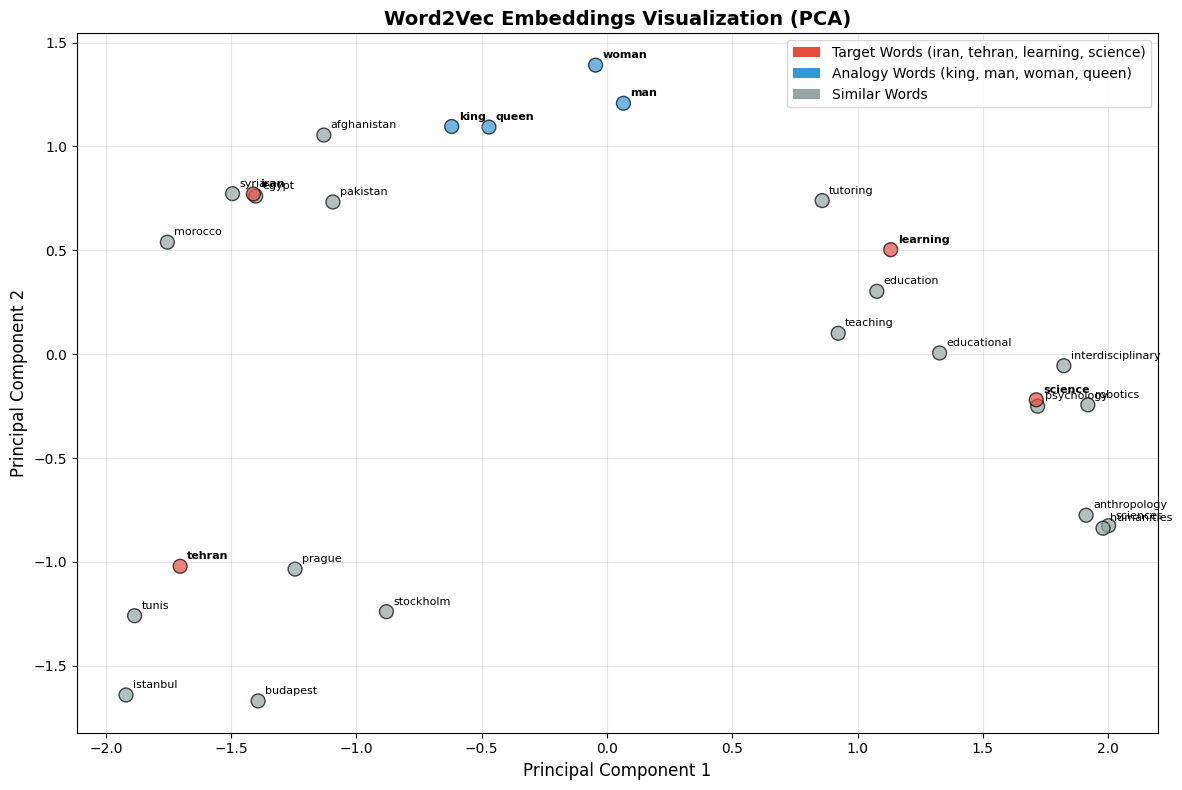


✅ Visualization saved as 'word2vec_visualization.png'


In [ ]:
# -----------------------------------------------------------------------------
# Bonus: Visualization of Word Embeddings (Optional)
# -----------------------------------------------------------------------------

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("=" * 70)
print("📊 Bonus: Word Embedding Visualization")
print("=" * 70)

# Collect all target words and their similar words for visualization
words_to_visualize = set(target_words)
for word in target_words:
    if word in all_similarities and all_similarities[word]:
        for row in all_similarities[word]:
            words_to_visualize.add(row['word'])

# Add analogy words
words_to_visualize.update(analogy_words)

# Get vectors for visualization
viz_words = []
viz_vectors = []

for word in words_to_visualize:
    word_vector = vectors_df.filter(col("word") == word)
    if word_vector.count() > 0:
        vec = word_vector.select("vector").first()[0].toArray()
        viz_words.append(word)
        viz_vectors.append(vec)

if len(viz_vectors) > 0:
    viz_vectors = np.array(viz_vectors)

    # Reduce to 2D using PCA
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(viz_vectors)

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 8))

    # Define colors for different word categories
    colors = []
    for word in viz_words:
        if word in target_words:
            colors.append('#e74c3c')  # Red for target words
        elif word in analogy_words:
            colors.append('#3498db')  # Blue for analogy words
        else:
            colors.append('#95a5a6')  # Gray for similar words

    # Plot points
    scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
                        c=colors, s=100, alpha=0.7, edgecolors='black')

    # Add word labels
    for i, word in enumerate(viz_words):
        ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, fontweight='bold' if word in target_words or word in analogy_words else 'normal')

    ax.set_title('Word2Vec Embeddings Visualization (PCA)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Principal Component 1', fontsize=12)
    ax.set_ylabel('Principal Component 2', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Target Words (iran, tehran, learning, science)'),
        Patch(facecolor='#3498db', label='Analogy Words (king, man, woman, queen)'),
        Patch(facecolor='#95a5a6', label='Similar Words')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.savefig('word2vec_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Visualization saved as 'word2vec_visualization.png'")
else:
    print("⚠️ Not enough words found for visualization")

Applying t-SNE dimensionality reduction...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE transformation completed.


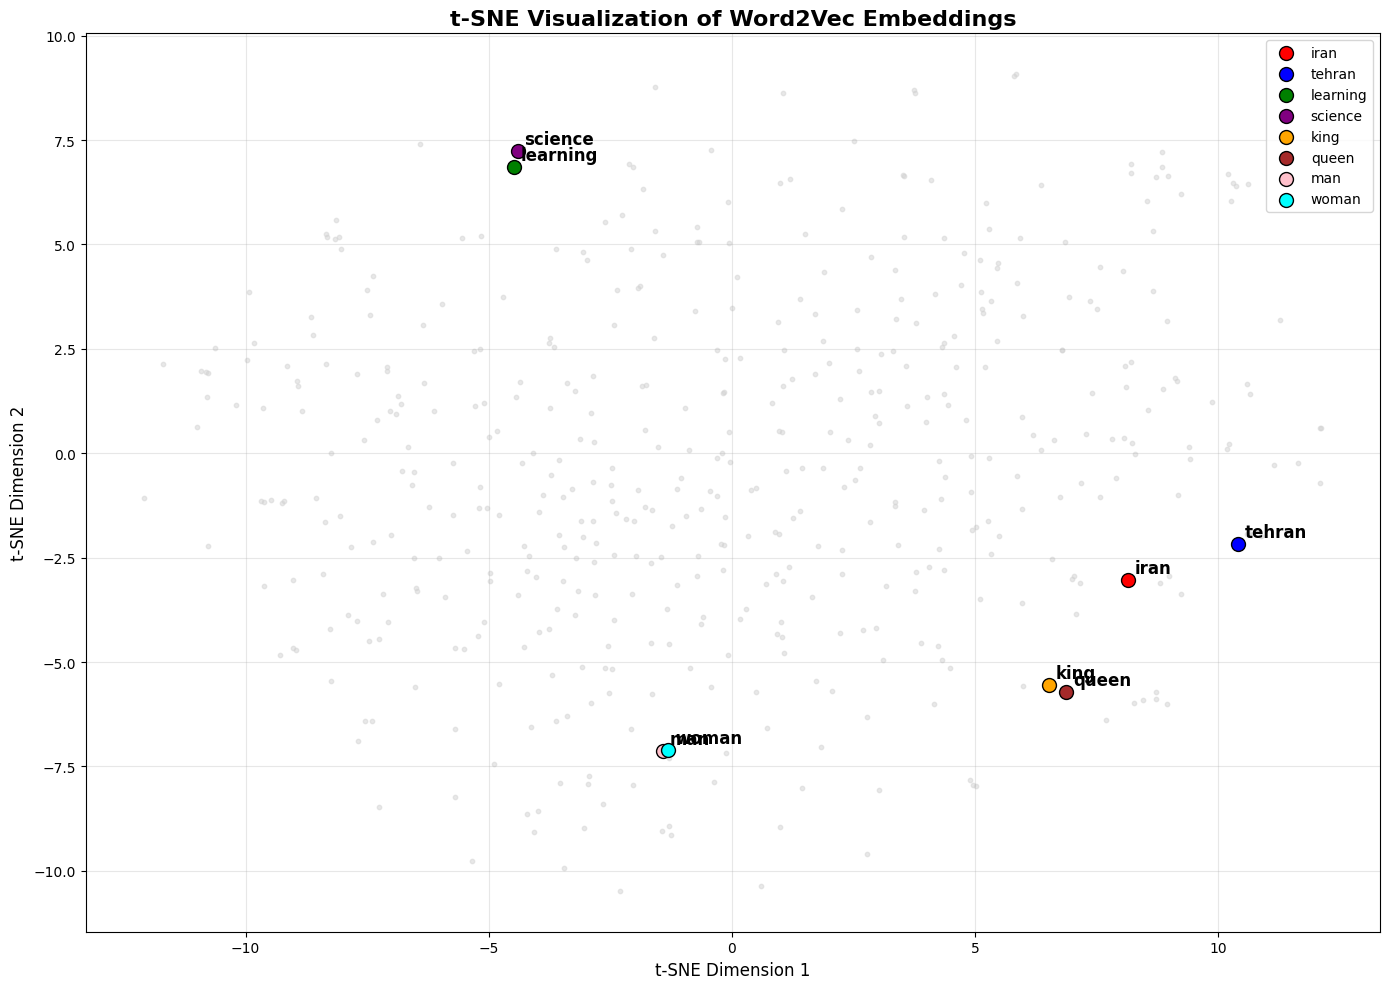

t-SNE visualization saved as 'tsne_word_embeddings.png'


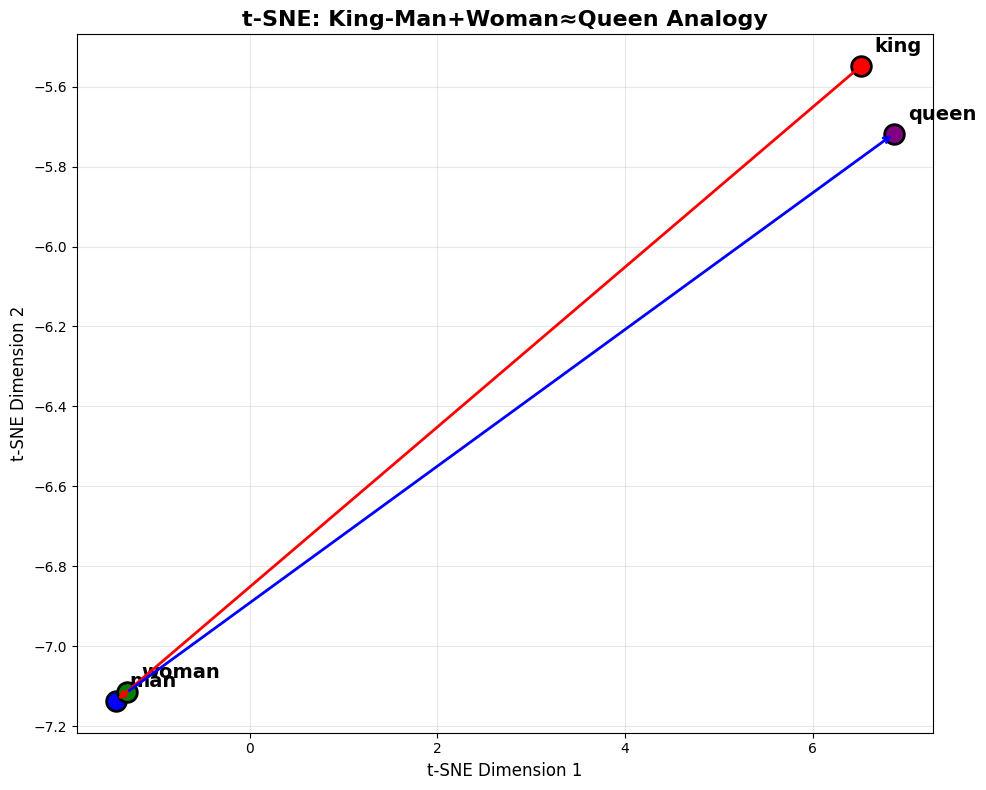

Analogy visualization saved as 'tsne_analogy_visualization.png'


In [5]:
# ============================================================
# t-SNE Visualization of Word Embeddings
# ============================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Get all word vectors from the model
word_vectors = model.getVectors()
words_df = word_vectors.collect()

# Extract words and their corresponding vectors
words = [row['word'] for row in words_df]
vectors = np.array([row['vector'].toArray() for row in words_df])

# Define target words for highlighting
target_words = ['iran', 'tehran', 'learning', 'science', 'king', 'queen', 'man', 'woman']

# Filter to get a manageable subset of words (top N most frequent or all if small)
# For better visualization, we select a subset including our target words
max_words = 500  # Adjust based on your needs

# Ensure target words are included
target_indices = [i for i, w in enumerate(words) if w.lower() in target_words]
other_indices = [i for i, w in enumerate(words) if w.lower() not in target_words][:max_words - len(target_indices)]
selected_indices = target_indices + other_indices

selected_words = [words[i] for i in selected_indices]
selected_vectors = vectors[selected_indices]

# Apply t-SNE dimensionality reduction
print("Applying t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
vectors_2d = tsne.fit_transform(selected_vectors)
print("t-SNE transformation completed.")

# Create the visualization
plt.figure(figsize=(14, 10))

# Plot all words as small gray points
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='lightgray', alpha=0.5, s=10)

# Highlight and annotate target words
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan']
for idx, target_word in enumerate(target_words):
    if target_word in selected_words:
        word_idx = selected_words.index(target_word)
        plt.scatter(vectors_2d[word_idx, 0], vectors_2d[word_idx, 1],
                   c=colors[idx % len(colors)], s=100, label=target_word, edgecolors='black', linewidths=1)
        plt.annotate(target_word,
                    (vectors_2d[word_idx, 0], vectors_2d[word_idx, 1]),
                    fontsize=12, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

plt.title('t-SNE Visualization of Word2Vec Embeddings', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_word_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()

print("t-SNE visualization saved as 'tsne_word_embeddings.png'")

# ============================================================
# Additional: t-SNE for Analogy Visualization (King-Man+Woman=Queen)
# ============================================================

# Visualize the analogy relationship
analogy_words = ['king', 'man', 'woman', 'queen']
analogy_indices = [selected_words.index(w) for w in analogy_words if w in selected_words]

if len(analogy_indices) == 4:
    plt.figure(figsize=(10, 8))

    # Plot analogy words
    analogy_vectors_2d = vectors_2d[analogy_indices]

    for i, word in enumerate(analogy_words):
        plt.scatter(analogy_vectors_2d[i, 0], analogy_vectors_2d[i, 1],
                   s=200, c=colors[i], edgecolors='black', linewidths=2)
        plt.annotate(word,
                    (analogy_vectors_2d[i, 0], analogy_vectors_2d[i, 1]),
                    fontsize=14, fontweight='bold',
                    xytext=(10, 10), textcoords='offset points')

    # Draw arrows to show the analogy relationship
    # king -> man (subtract)
    plt.annotate('', xy=analogy_vectors_2d[1], xytext=analogy_vectors_2d[0],
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    # woman -> queen (result direction)
    plt.annotate('', xy=analogy_vectors_2d[3], xytext=analogy_vectors_2d[2],
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

    plt.title('t-SNE: King-Man+Woman≈Queen Analogy', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('tsne_analogy_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Analogy visualization saved as 'tsne_analogy_visualization.png'")

In [ ]:
# -----------------------------------------------------------------------------
# Cleanup: Stop Spark Session
# -----------------------------------------------------------------------------

spark.stop()
print("\n" + "=" * 60)
print("✅ Spark Session stopped successfully!")
print("✅ Question 2 (Word2Vec) completed!")
print("=" * 60)


✅ Spark Session stopped successfully!
✅ Question 2 (Word2Vec) completed!
